Author: Daniel Abadjiev  
Date: September 24, 2026  
Description: Testing out stuff with student and teacher models for smartpix.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import qkeras
import sys
sys.path.append("../MuC_Smartpix_ML")
sys.path.append("../eric")
sys.path.append("../ryan")
import Model_Classes
from model1 import Model1
from model2 import Model2
from model3 import Model3
from model2_5 import Model2_5
from ASICModel import ModelASIC
import tfLoaderUtils
import distillers
tfRecordFolder="/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/"


sys.path.append("../MuC_Smartpix_Data_Production/tfRecords")
import OptimizedDataGenerator4_data_shuffled_bigData_NewFormat as ODG2

2026-09-25 09:24:55.707180: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 09:24:55.747087: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
weird import error
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


2026-09-25 09:24:57.875967: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /device:GPU:0 with 14216 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:4b:00.0, compute capability: 8.6


### Original testing

In [2]:
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_10bit_normalised_selected/pareto_primary/FailedTrialsRetryIfCoureageous/model_trial_086.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_10bit_normalised_selected/pareto_primary/FailedTrialsRetryIfCoureageous/model_trial_095.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_10bit_normalised_selected/pareto_primary/model_trial_084.h5"

# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_8bit_normalised_selected/pareto_primary/model_trial_009.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_8bit_normalised_selected/pareto_primary/model_trial_019.h5"

teacher = Model_Classes.loadQuantizedModel(filepath)
# teacher.summary()
def numOutNodes(model):
    outputLayerNodes = model.layers[-2].input_spec.axes[-1]
    return outputLayerNodes;
print(numOutNodes(teacher))

filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model1_fin_results/model1_8bit_normalised_selected/pareto_primary/model_trial_1047.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model1_fin_results/model1_8bit_normalised_selected/pareto_primary/model_trial_1046.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model1_fin_results/model1_8bit_normalised_selected/pareto_primary/model_trial_1042.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model1_fin_results/model1_8bit_normalised_selected/pareto_primary/model_trial_1048.h5"
# filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model1_fin_results/model1_8bit_normalised_selected/pareto_secondary/model_trial_1059.h5"

student = Model_Classes.loadQuantizedModel(filepath)
# student.summary()
print(numOutNodes(student))


2026-09-25 09:04:52.768911: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14216 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:4b:00.0, compute capability: 8.6


18
10


In [ ]:

xTest_m1, yTest_m1, xTestList_m1, xTrain_m1, yTrain_m1 = tfLoaderUtils.flattenTfData(1,tfRecordFolder=tfRecordFolder)
xTest_m3, yTest_m3, xTestList_m3, xTrain_m3, yTrain_m3 = tfLoaderUtils.flattenTfData(3,tfRecordFolder=tfRecordFolder)
            

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Warning! Not accounting for possible filteredTime


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Warning! Not accounting for possible filteredTime


In [ ]:
configName = "justThisOne"
# tmodel = Model3(tfRecordFolder = tfRecordFolder) 
# tmodel.models[configName] = teacher
# tmodel.evaluate(config_name=configName,predictionPlots=False,signal_efficiencies=[0.95, 0.98, 0.99])
# # predictions = model.models[configName].predict(model.validation_generator, verbose=1)
# predictions = tmodel.predictions
# predictionsTeacherLong = teacher.predict(xTrain_m3)
# print(predictionsTeacherLong)

In [69]:
tmodel = Model3(tfRecordFolder = tfRecordFolder) 
tmodel.models[configName] = teacher
# tmodel.evaluate(config_name=configName,predictionPlots=False,signal_efficiencies=[0.95, 0.98, 0.99])
tmodel.loadTfRecords()
predictionsTeacher = tmodel.models[configName].predict(tmodel.training_generator, verbose=1)
# np.nonzero(predictionsTeacherLong - predictionsTeacher) #confirms the same and this is much Faster

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
162/162 [==============================] - 9s 56ms/step


In [3]:
initial_lr = 1e-3
# epochs = 1
# steps_per_epoch = X_train.shape[0] // 512
# lr_schedule = CosineDecay(
#     initial_learning_rate=initial_lr,
#     decay_steps=epochs * steps_per_epoch,
#     alpha=1e-4
# )

# optimizer = Adam(learning_rate=lr_schedule)
optimizer = tf.keras.optimizers.Adam()

# inputs = layers.Input(shape=input_shape)
# x = layers.Flatten()(inputs)


# x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# x = layers.Dropout(0.1)(x)
# x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# x = layers.Dropout(0.1)(x)

# x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# x = layers.Dropout(0.1)(x)

# student= models.Model(inputs,x)
# student.compile(
#     optimizer=optimizer,
#     loss="mse",
#     metrics=["mae"]
# )

from qkeras import QDense, QActivation, quantized_bits, quantized_relu, quantized_tanh
def constructModel (
            input_bits = 12,
            w_bits = 10,
            rownodes = 10,
            hintNodes = numOutNodes(teacher),):

    input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
    input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
    input3 = tf.keras.layers.Input(shape=(1,), name="y_size")
    input4 = tf.keras.layers.Input(shape=(1,), name="y_local")
    # input5 = tf.keras.layers.Input(shape=(1,), name="nModule")
    # input6 = tf.keras.layers.Input(shape=(1,), name="x_local")

    # inputList = [input2, input3, input4, input5, input6]
    inputList = [input2, input3, input4]

    #q_input1 = QActivation(activation=quantized_bits(self.input_bits, 0), name="q_input_1")(input1)
    q_input2 = QActivation(activation=quantized_bits(input_bits, 0), name="q_input_2")(input2)
    q_input3 = QActivation(activation=quantized_bits(input_bits, 0), name="q_input_3")(input3)
    q_input4 = QActivation(activation=quantized_bits(input_bits, 0), name="q_input_4")(input4)
    # q_input5 = QActivation(activation=quantized_bits(input_bits, 0), name="q_input_5")(input5)
    # q_input6 = QActivation(activation=quantized_bits(input_bits, 0), name="q_input_6")(input6)

    x_concat1 = tf.keras.layers.Concatenate()([q_input2, q_input3])
    x_concat2 = tf.keras.layers.Concatenate()([x_concat1, q_input4])
    # x_concat3 = tf.keras.layers.Concatenate()([x_concat2, q_input5])
    # x_concat4 = tf.keras.layers.Concatenate()([x_concat3, q_input6])
    x=x_concat2

    # layer 1
    x = QDense(
    rownodes,
    kernel_quantizer=quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=quantized_bits(w_bits, 0, alpha=1),
    )(x)
    x = QActivation(
    activation=quantized_relu(8, 0),
    name="q_relu1"
    )(x)
    ## layer 2
    x = QDense(
    hintNodes,
    kernel_quantizer=quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=quantized_bits(w_bits, 0, alpha=1),
    )(x)
    x = QActivation(
    activation=quantized_relu(8, 0),
    name="q_relu2"
    )(x)
    ## output layer
    x = QDense(
    1,
    kernel_quantizer=quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=quantized_bits(w_bits, 0, alpha=1),
    )(x)


    ## output later
    output = QActivation("quantized_sigmoid(8,0)", name="output_activation")(x)

    model = tf.keras.Model(inputs=inputList, outputs=output)
    return model
student = constructModel()


In [ ]:
#xTest_m1, yTest_m1, xTestList_m1, xTrain_m1, yTrain_m1
epochs = 30
student.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)
history = student.fit(
    xTrain_m1, predictionsTeacher,
    validation_data=(xTest_m1, yTest_m1),
    epochs=epochs,
    batch_size=8192,  # The ratio of learning rate to batch size controls the “temperature” of the optimiser: higher values promote exploration. Temperature also affects the geometry of the minima. Paper: https://openreview.net/references/pdf?id=S1UD-XWCZ
    shuffle=True,
    callbacks=[]
)

Epoch 1/30


/home/dabadjiev/miniconda3/envs/mlgpu_qkeras_tar/lib/python3.8/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['z_global'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


324/324 [==============================] - 2s 4ms/step - loss: 0.1643 - mae: 0.3759 - val_loss: 0.1754 - val_mae: 0.3653
Epoch 2/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1315 - mae: 0.2974 - val_loss: 0.1655 - val_mae: 0.3401
Epoch 3/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1260 - mae: 0.2814 - val_loss: 0.1619 - val_mae: 0.3315
Epoch 4/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1232 - mae: 0.2750 - val_loss: 0.1597 - val_mae: 0.3254
Epoch 5/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1218 - mae: 0.2712 - val_loss: 0.1587 - val_mae: 0.3221
Epoch 6/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1209 - mae: 0.2688 - val_loss: 0.1579 - val_mae: 0.3199
Epoch 7/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1203 - mae: 0.2671 - val_loss: 0.1574 - val_mae: 0.3182
Epoch 8/30
324/324 [==============================] - 1s 3ms/step - loss: 0.1199 - mae:

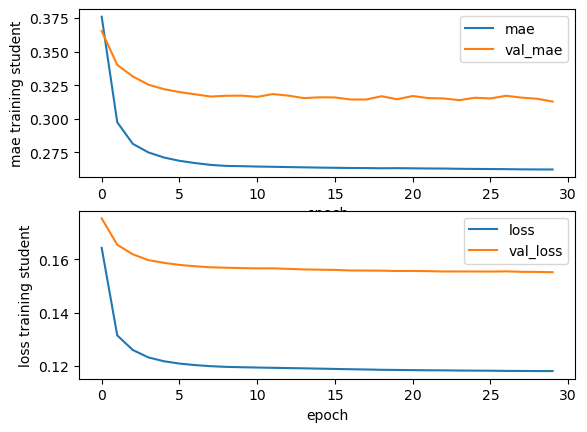

In [93]:
plt.subplot(211)
plt.plot(history.history["mae"],label="mae")
plt.plot(history.history["val_mae"],label="val_mae")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("mae training student")
plt.subplot(212)
plt.plot(history.history['loss'],label="loss")
plt.plot(history.history['val_loss'],label="val_loss")
plt.ylabel("loss training student")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [95]:
smodel = Model1(tfRecordFolder = tfRecordFolder) 
smodel.models[configName] = student
smodel.evaluate(config_name=configName,predictionPlots=False,signal_efficiencies=[0.95, 0.98, 0.99])
# smodel.loadTfRecords()
# predictionsS = tmodel.models[configName].predict(tmodel.training_generator, verbose=1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Evaluating Model1 [justThisOne]...
41/41 [==============================] - 2s 54ms/step


Data rate at fpr 0.41954580774684724 and threshold [0.5234375]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Data rate at fpr 0.4510236106197901 and threshold [0.47265625]
Data rate at fpr 0.4771437469197953 and threshold [0.3125]
✓ Model1 evaluation completed!
  Test Loss: 0.1552
  Test Accuracy: 0.3128
  ROC AUC: 0.8305

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 95% signal efficiency: Bkg Rej = 0.5805 (FPR = 0.419546), Back Data Accep = 0.2540
    @ 98% signal efficiency: Bkg Rej = 0.5490 (FPR = 0.451024), Back Data Accep = 0.2696
    @ 99% signal efficiency: Bkg Rej = 0.5229 (FPR = 0.477144), Back Data Accep = 0.2837


{'test_loss': 0.15520240366458893,
 'test_accuracy': 0.31283941864967346,
 'roc_auc': 0.8304886340048113,
 'fpr': [0.0,
  9.977595762242964e-05,
  0.00022071651231628375,
  0.0003567746363468696,
  0.0005170208713162263,
  0.0006954081894896611,
  0.0007044787310917001,
  0.0007619254945712808,
  0.0007709960361733199,
  0.0010763709367753015,
  0.0017415439875914992,
  0.002811867896632108,
  0.0040001088464992245,
  0.004659234869580729,
  0.005536053891111172,
  0.005956322318672314,
  0.006282861816345721,
  0.006479390217723233,
  0.006914776214621108,
  0.0076253019734475016,
  0.00821488717758004,
  0.008807495895579925,
  0.010397864189804106,
  0.011800774624252814,
  0.013315555071793337,
  0.01440704357790537,
  0.01609718782975198,
  0.01687725440752734,
  0.019410959028363584,
  0.02189326391345494,
  0.025207035112066543,
  0.027441411860035497,
  0.028792922558739317,
  0.029524612914637132,
  0.0303379381449533,
  0.03090333523814707,
  0.031462685303606144,
  0.0326660

### Claude distillers version

In [6]:
tfRecordFolder="/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Results_June2026_99SigEff/model3_fin_results/model3_10bit_normalised_selected/pareto_primary/FailedTrialsRetryIfCoureageous/model_trial_095.h5"
teacher = Model_Classes.loadQuantizedModel(filepath)
def numOutNodes(model):
    outputLayerNodes = model.layers[-2].input_spec.axes[-1]
    return outputLayerNodes;


In [7]:
def numOutNodes(model):
    outputLayerNodes = model.layers[-2].input_spec.axes[-1]
    return outputLayerNodes;
def constructModel (
            input_bits = 12,
            w_bits = 10,
            rownodes = 10,
            hintNodes = numOutNodes(teacher),):

    input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
    input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
    input3 = tf.keras.layers.Input(shape=(1,), name="y_size")
    input4 = tf.keras.layers.Input(shape=(1,), name="y_local")
    # input5 = tf.keras.layers.Input(shape=(1,), name="nModule")
    # input6 = tf.keras.layers.Input(shape=(1,), name="x_local")

    # inputList = [input2, input3, input4, input5, input6]
    inputList = [input2, input3, input4]

    #q_input1 = QActivation(activation=quantized_bits(self.input_bits, 0), name="q_input_1")(input1)
    q_input2 = qkeras.QActivation(activation=qkeras.quantized_bits(input_bits, 0), name="q_input_2")(input2)
    q_input3 = qkeras.QActivation(activation=qkeras.quantized_bits(input_bits, 0), name="q_input_3")(input3)
    q_input4 = qkeras.QActivation(activation=qkeras.quantized_bits(input_bits, 0), name="q_input_4")(input4)
    # q_input5 = QActivation(activation=qkeras.quantized_bits(input_bits, 0), name="q_input_5")(input5)
    # q_input6 = QActivation(activation=qkeras.quantized_bits(input_bits, 0), name="q_input_6")(input6)

    x_concat1 = tf.keras.layers.Concatenate()([q_input2, q_input3])
    x_concat2 = tf.keras.layers.Concatenate()([x_concat1, q_input4])
    # x_concat3 = tf.keras.layers.Concatenate()([x_concat2, q_input5])
    # x_concat4 = tf.keras.layers.Concatenate()([x_concat3, q_input6])
    x=x_concat2

    # layer 1
    x = qkeras.QDense(
    rownodes,
    kernel_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    )(x)
    x = qkeras.QActivation(
    activation=qkeras.quantized_relu(8, 0),
    name="q_relu1"
    )(x)
    ## layer 2
    x = qkeras.QDense(
    hintNodes,
    kernel_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    )(x)
    x = qkeras.QActivation(
    activation=qkeras.quantized_relu(8, 0),
    name="q_relu2"
    )(x)
    ## output layer
    x = qkeras.QDense(
    1,
    kernel_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    bias_quantizer=qkeras.quantized_bits(w_bits, 0, alpha=1),
    )(x)


    ## output later
    output = qkeras.QActivation("quantized_sigmoid(8,0)", name="output_activation")(x)

    model = tf.keras.Model(inputs=inputList, outputs=output)
    return model
# --- Step 0: build student (quantized, matching teacher's input features) ---
student = constructModel()

In [ ]:
d = distillers.OfflineDistiller(teacher, student,
                             temperature=3.0, alpha=0.5, beta=0.1)

model1Dummy = Model1(tfRecordFolder = tfRecordFolder)     
model3Dummy = Model3(tfRecordFolder = tfRecordFolder)    
model1Dummy.x_feature_description = model1Dummy.x_feature_description + ["z_global"] + model3Dummy.x_feature_description + ["nPix"]
model1Dummy.loadTfRecords()
odgTrain = model1Dummy.training_generator
odgTest = model1Dummy.validation_generator

augTfRecordDir = "./augRecords"
augTrainDir = f"{augTfRecordDir}/tfrecords_train/"
augValDir = f"{augTfRecordDir}/tfrecords_validation/"


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41


In [9]:
regenerateRecords=False
if regenerateRecords:
    d.extract_and_save_teacher_outputs(
        training_generator=odgTrain,
        output_dir=augTrainDir,
        validation_generator=odgTest,
        val_output_dir=augValDir,
    )

In [10]:
# augModelDummy = model1Dummy
# augModelDummy.x_feature_description = model1Dummy.x_feature_description + ["teacher_logits", "teacher_feat"]
# augModelDummy.tfRecordFolder = augTfRecordDir;
# augModelDummy.loadTfRecords()
aug_train_gen = ODG2.OptimizedDataGeneratorDataShuffledBigData(
    load_records=True,
    tf_records_dir=augTrainDir,
    x_feature_description=model1Dummy.x_feature_description + ["teacher_logits", "teacher_feat"],
    batch_size=16384,
)
aug_val_gen = ODG2.OptimizedDataGeneratorDataShuffledBigData(
    load_records=True,
    tf_records_dir=augValDir,
    x_feature_description=model1Dummy.x_feature_description + ["teacher_logits", "teacher_feat"],
    batch_size=16384,
)

In [11]:
model = d.build_student_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    student_loss_fn=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy()],
    run_eagerly=True,  # required for QKeras models
)
model.fit(aug_train_gen,
        validation_data=aug_val_gen,
        epochs=2)


Epoch 1/2


2026-09-25 09:26:53.640167: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-09-25 09:26:53.973213: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f1d2c027f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-25 09:26:53.973259: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2026-09-25 09:26:53.977947: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-25 09:26:53.993228: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2026-09-25 09:26:54.074712: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

162/162 [==============================] - 16s 97ms/step - binary_accuracy: 0.5000 - val_binary_accuracy: 0.5000
Epoch 2/2
162/162 [==============================] - 16s 96ms/step - binary_accuracy: 0.5000 - val_binary_accuracy: 0.5000
